In [1]:
# Import the necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from transformers import CLIPTokenizer

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")


In [2]:
# Load the photos JSON file
metadata_path =  "./Yelp Photos/photos.json"
df = pd.read_json(metadata_path, lines=True)

In [3]:
# Dataset Class to define how to load and process data samples one at a time
class YelpJSONDataset(Dataset):
    """
    Dataset for Yelp photos using a JSON lines metadata file.
    Loads image from image_dir using 'photo_id', and returns image, label, and caption.
    """

    def __init__(self, dataframe, image_dir, transform=None, tokenizer=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        photo_id = row["photo_id"]
        image_path = os.path.join(self.image_dir, f"{photo_id}.jpg")

        # Load and transform image
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Get label and caption
        label = row["label"]
        caption = row["caption"]

        # Optional caption tokenization (for text-to-image model)
        if self.tokenizer:
            caption = self.tokenizer(
                caption,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=77
            )

        return image, label, caption

In [4]:
# Function to split the data
from sklearn.model_selection import train_test_split

def split_json_df(df, test_size=0.2, random_state=42):
    """
    Stratified train-test split based on label column for balanced distribution of labels.
    """
    return train_test_split(df, test_size=test_size, stratify=df["label"], random_state=random_state)

In [5]:
# Model-specific preprocessing functions

def preprocess_ddpm(train_df, test_df, image_dir):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return YelpJSONDataset(train_df, image_dir, transform), YelpJSONDataset(test_df, image_dir, transform)

def preprocess_ddim(train_df, test_df, image_dir):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return YelpJSONDataset(train_df, image_dir, transform), YelpJSONDataset(test_df, image_dir, transform)

def preprocess_latent_diffusion(train_df, test_df, image_dir):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return YelpJSONDataset(train_df, image_dir, transform), YelpJSONDataset(test_df, image_dir, transform)

def preprocess_text_to_image(train_df, test_df, image_dir, tokenizer):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return YelpJSONDataset(train_df, image_dir, transform, tokenizer), YelpJSONDataset(test_df, image_dir, transform, tokenizer)

In [6]:

# # Load data
# df = pd.read_json(metadata_path, lines=True)

# Split
train_df, test_df = split_json_df(df)

# Define Image directory
image_dir = "./Yelp Photos/photos"

# Tokenizer for GLIDE
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# Run all preprocessors
train_ddpm, test_ddpm = preprocess_ddpm(train_df, test_df, image_dir)
train_ddim, test_ddim = preprocess_ddim(train_df, test_df, image_dir)
train_ldm, test_ldm = preprocess_latent_diffusion(train_df, test_df, image_dir)
train_glide, test_glide = preprocess_text_to_image(train_df, test_df, image_dir, tokenizer)

In [7]:
# Preview function to show smple photos
def show_sample_images(dataset, num_samples=5, show_caption=True):
    """
    Plots sample images from the dataset with their labels and captions.
    
    Args:
        dataset (Dataset): Pytorch dataset with __getitem__ returning (image, label, caption)
        num_samples (int): Number of samples to display
        show_caption (bool): Whether to display caption under label
    """
    plt.figure(figsize=(15,3))
    for i in range(num_samples):
        image, label, caption = dataset[i]

        # Convert image tensor to numpy
        image = image.numpy().transpose(1, 2, 0)
        # image = (image * 0.5) # Unnormalize from [-1, 1] to [0, 1]
        image = image + 0.5 # Assuming image is normalized to [-0.5, 0.5], scale to [0,1] for display
        image = np.clip(image, 0,1)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image)
        plt.axis('off')

        # if caption is tokenized dict, extract 'input_ids' and decode
        if isinstance(caption, dict):
            try:
                input_ids = caption["input_ids"][0]
                caption_text = tokenizer.decode(input_ids, skip_special_tokens=True)
            except Exception:
                caption_text = "<tokenized>"
        else:
            caption_text = caption if caption else "<no caption>"

        title = f"Label: {label}"
        if show_caption:
            title+= f"n\Cap: {caption_text[:30]}..."
        plt.title(title, fontsize=10)
    plt.tight_layout()
    plt.show()

DDPM Samples:


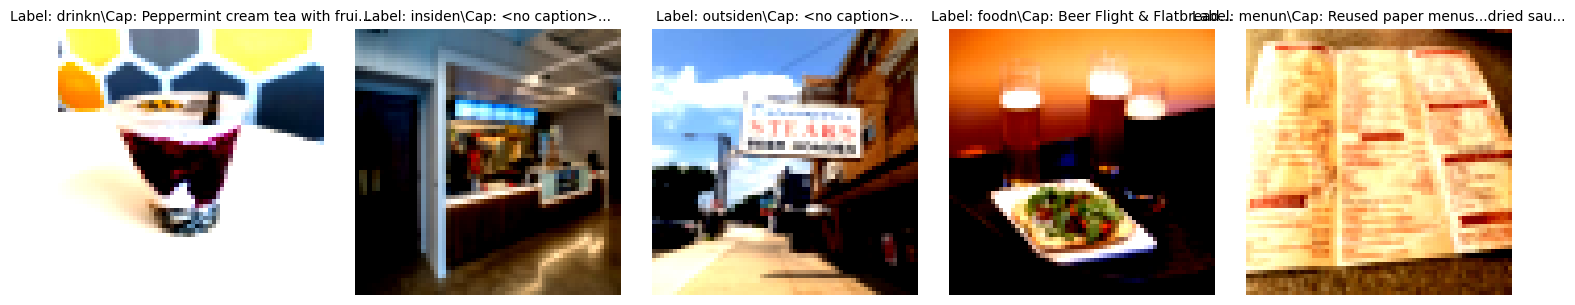

DDIM Samples:


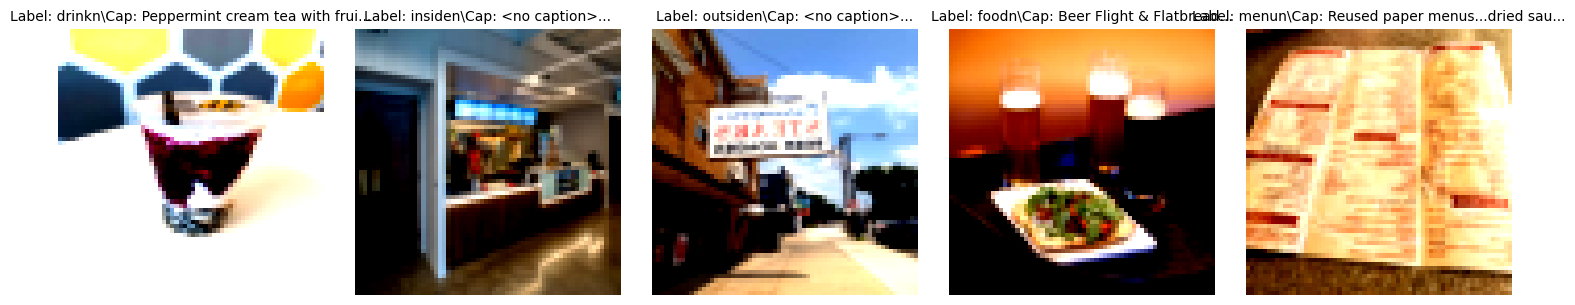

Latent Diffusion Samples:


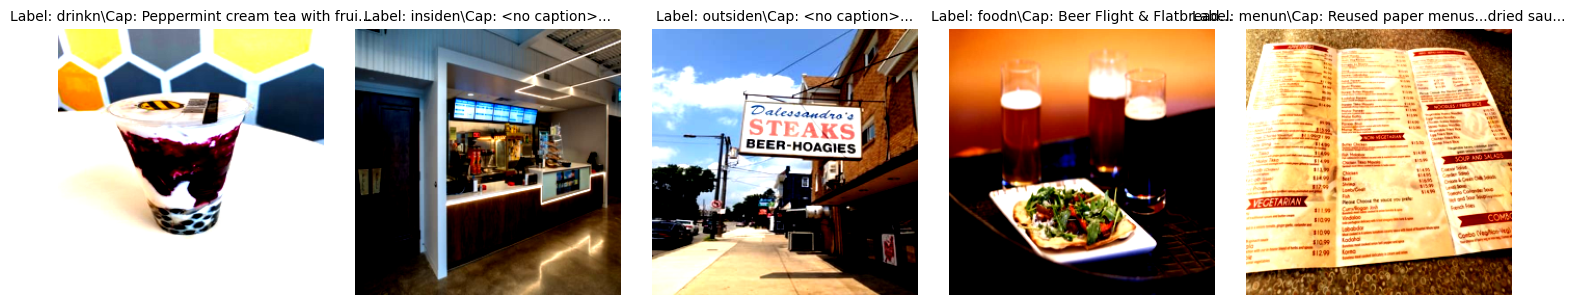

Text-to-image Diffusion Samples:


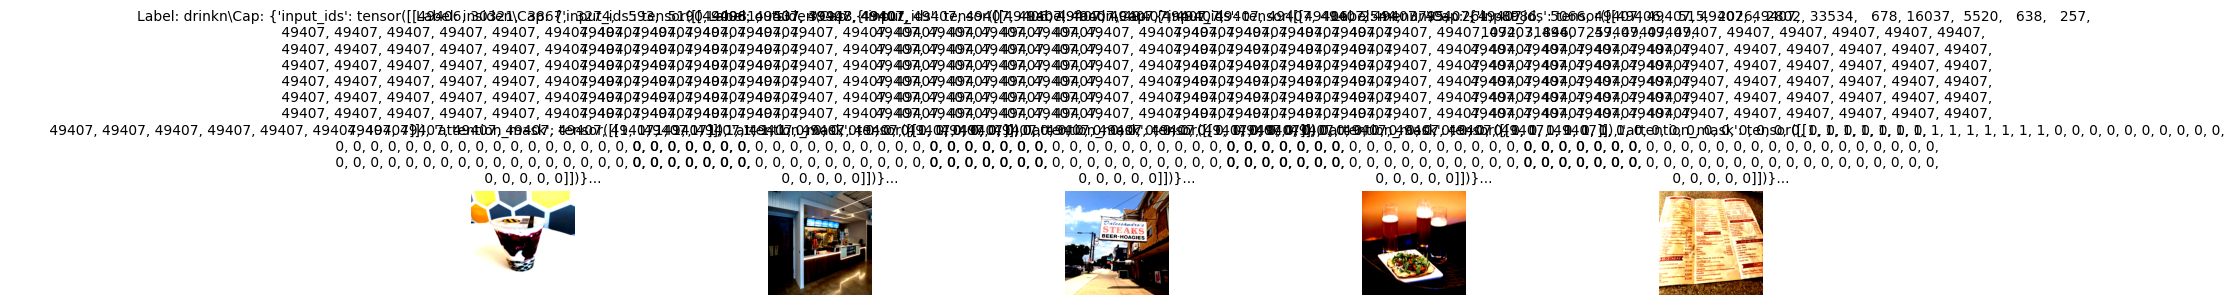

In [8]:
# Preview samples for each preprocessed dataset

# DDPM
print("DDPM Samples:")
show_sample_images(train_ddpm)

# DDIM
print("DDIM Samples:")
show_sample_images(train_ddim)

# Latent Diffusion
print("Latent Diffusion Samples:")
show_sample_images(train_ldm)

# Text-to-Image (FLIDE or similar)
print("Text-to-image Diffusion Samples:")
show_sample_images(train_glide, show_caption=True)

In [9]:
# Exporting the datasets for later use:
# Option 1: Saving as Pytorch Objects
import torch

torch.save(train_ddpm, "train_ddpm.pt")
torch.save(test_ddpm, "test_ddpm.pt")

torch.save(train_ddim, "train_ddim.pt")
torch.save(test_ddim, "test_ddim.pt")

torch.save(train_ldm, "train_ldm.pt")
torch.save(test_ldm, "test_ldm.pt")

torch.save(train_glide, "train_glide.pt")
torch.save(test_glide, "test_glide.pt")

# Option 2: Saving the test and train csv files (underlying data)
train_df.to_csv("train_metadata.csv", index=False)
test_df.to_csv("test_metadata.csv", index=False)

In [50]:
# Note to colleagues:
# If using PyTorch, get the dataset objects directly using torch.load("train_ddpm.pt") for example.
# If using the underlying data,run the preprocessing step for your model.